In [1]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import unicodedata
import re

In [2]:
#Dataframe de rutas comerciales

data = [
    [10264, "614"],
    [10342, "KB309"],
    [10350, "SE14"],
    [10689, "DH216"],
    [10550, "P500"],
    [10266, "DD204"],
    [10551, "KL307"],
    [10360, "5-abr"],
    [10354, "16-may"],
    [10690, "DL219"],
    [10282, "DH209"],
    [10311, "DA213"],
    [10331, "12"],
    [10232, "359"],
    [10325, "576"],
    [10305, "DD212"],
    [10688, "BD237"],
    [10273, "142"],
    [10244, "SE10"],
    [10261, "466"],
    [10204, "402"],
    [10691, "DA218"],
    [10196, "E25"],
    [10184, "740"],
    [10310, "C101"],
    [10304, "806"],
    [10194, "539"],
    [10292, "577"],
    [10339, "C25"],
    [10474, "16-2 Engativa Centro"],
    [10502, "16-6 La Faena"],
    [10488, "16-4 El Muelle"],
    [10492, "16-1 Tierra Grata"],
    [10478, "16-3 Av. Eldorado Alamos"],
    [10495, "16-14 Aeropuerto"],
    [10504, "1-1 Alamos"],
    [10527, "1-9 Villas del Dorado"],
]

df_lineas = pd.DataFrame(data, columns=["Id Línea", "Nombre Línea"])

df_lineas.head()

,Id Línea,Nombre Línea
0,10264,614
1,10342,KB309
2,10350,SE14
3,10689,DH216
4,10550,P500


In [3]:
#datos de ingreso
dia_ivd = '20260301'
dia_fvd = '20260413'

In [4]:
# Ruta de la carpeta que contiene los archivos de desglosados zonal
ruta_carpeta = 'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_regularidad'

# Fechas de inicio y fin para el filtro
fecha_inicio = f'{dia_ivd}'
fecha_fin = f'{dia_fvd}'

# Lista para almacenar los DataFrames
dataframes = []

# Recorrer todos los archivos en la carpeta
for nombre_archivo in os.listdir(ruta_carpeta):

    if nombre_archivo.endswith('_seguimiento_regularidad.csv'):

        # Extraer la fecha del nombre del archivo (YYYYMMDD)
        fecha_archivo = nombre_archivo[:8]

        # Verificar si la fecha está dentro del rango deseado
        if fecha_inicio <= fecha_archivo <= fecha_fin:

            ruta_archivo = os.path.join(ruta_carpeta, nombre_archivo)

            # Leer el archivo
            df = pd.read_csv(ruta_archivo, encoding='latin',sep=';')

            # Eliminar filas completamente vacías
            df = df.dropna(how='all')

            # Crear la columna Fecha a partir del nombre del archivo
            df['Fecha'] = pd.to_datetime(fecha_archivo, format='%Y%m%d')

            # Agregar a la lista
            dataframes.append(df)

# Verificar si se encontraron DataFrames
if dataframes:
    # Consolidar todos los DataFrames en uno solo
    perdidos_reg = pd.concat(dataframes, ignore_index=True)
else:
    print("No se encontraron archivos para consolidar.")

# Verificar resultado
perdidos_reg.head()

,instante,servbus,evento,linea,coche,sublinea,ruta,punto,viaje,fecha,...,viaje_final,intervalo_real_paso,limite_inferior,limite_superior,min_primer_despacho_regulado,max_primer_despacho_regulado,min_ultimo_despacho_regulado,max_ultimo_despacho_regulado,regularidad,Fecha
0,2026-03-09 06:49:45,CE1600001,3,10184,1,2521,12774,52845,3,2026-03-09,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2026-03-09
1,2026-03-09 19:00:15,CE1600006,3,10184,6,2521,12774,52845,5,2026-03-09,...,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2026-03-09
2,2026-03-09 08:07:15,CE1600010,3,10184,10,2521,12774,52845,3,2026-03-09,...,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2026-03-09
3,2026-03-09 13:33:15,CE1600010,3,10184,10,2521,12774,52845,4,2026-03-09,...,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2026-03-09
4,2026-03-09 04:08:45,CE1600012,11,10184,12,2521,12774,52845,2,2026-03-09,...,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2026-03-09


In [5]:
# Crear diccionario Id Línea -> Nombre Línea
map_lineas = dict(zip(df_lineas["Id Línea"], df_lineas["Nombre Línea"]))

# Crear nueva columna en acciones
perdidos_reg["ruta_comercial"] = perdidos_reg["linea"].map(map_lineas)

perdidos_reg.head()

,instante,servbus,evento,linea,coche,sublinea,ruta,punto,viaje,fecha,...,intervalo_real_paso,limite_inferior,limite_superior,min_primer_despacho_regulado,max_primer_despacho_regulado,min_ultimo_despacho_regulado,max_ultimo_despacho_regulado,regularidad,Fecha,ruta_comercial
0,2026-03-09 06:49:45,CE1600001,3,10184,1,2521,12774,52845,3,2026-03-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2026-03-09,740
1,2026-03-09 19:00:15,CE1600006,3,10184,6,2521,12774,52845,5,2026-03-09,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2026-03-09,740
2,2026-03-09 08:07:15,CE1600010,3,10184,10,2521,12774,52845,3,2026-03-09,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2026-03-09,740
3,2026-03-09 13:33:15,CE1600010,3,10184,10,2521,12774,52845,4,2026-03-09,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2026-03-09,740
4,2026-03-09 04:08:45,CE1600012,11,10184,12,2521,12774,52845,2,2026-03-09,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,2026-03-09,740


In [6]:
perdidos_reg = perdidos_reg.sort_values(
    by=["linea", "ruta", "instante_seg"]
).reset_index(drop=True)

perdidos_reg.head()

,instante,servbus,evento,linea,coche,sublinea,ruta,punto,viaje,fecha,...,intervalo_real_paso,limite_inferior,limite_superior,min_primer_despacho_regulado,max_primer_despacho_regulado,min_ultimo_despacho_regulado,max_ultimo_despacho_regulado,regularidad,Fecha,ruta_comercial
0,2026-03-09 03:00:00,CE1600001,11,10184,1,2521,12774,52845,2,2026-03-09,...,10870.0,270.0,540.0,NaN,NaN,NaN,NaN,0,2026-03-09,740
1,2026-04-01 03:00:00,CE17E0001,11,10184,1,2521,12774,52845,2,2026-04-01,...,10855.0,337.5,675.0,NaN,NaN,NaN,NaN,0,2026-04-01,740
2,2026-04-06 03:00:00,CE1600001,11,10184,1,2521,12774,52845,2,2026-04-06,...,10909.0,337.5,675.0,NaN,NaN,NaN,NaN,0,2026-04-06,740
3,2026-04-07 03:00:00,CE1600001,11,10184,1,2521,12774,52845,2,2026-04-07,...,10750.0,2700.0,5400.0,NaN,NaN,NaN,NaN,0,2026-04-07,740
4,2026-04-08 03:00:00,CE1600001,11,10184,1,2521,12774,52845,2,2026-04-08,...,11009.0,270.0,540.0,NaN,NaN,NaN,NaN,0,2026-04-08,740


In [7]:
perdidos_reg = perdidos_reg.sort_values(
    by=["linea", "ruta", "ruta_comercial", "instante_seg"]
).reset_index(drop=True)

perdidos_reg["grupo"] = (
    perdidos_reg
        .groupby(["linea", "ruta", "ruta_comercial"])["marcado_eliminado"]
        .transform(lambda x: (x != x.shift()).cumsum())
)

perdidos_reg.head()

,instante,servbus,evento,linea,coche,sublinea,ruta,punto,viaje,fecha,...,limite_inferior,limite_superior,min_primer_despacho_regulado,max_primer_despacho_regulado,min_ultimo_despacho_regulado,max_ultimo_despacho_regulado,regularidad,Fecha,ruta_comercial,grupo
0,2026-03-09 03:00:00,CE1600001,11,10184,1,2521,12774,52845,2,2026-03-09,...,270.0,540.0,NaN,NaN,NaN,NaN,0,2026-03-09,740,1
1,2026-04-01 03:00:00,CE17E0001,11,10184,1,2521,12774,52845,2,2026-04-01,...,337.5,675.0,NaN,NaN,NaN,NaN,0,2026-04-01,740,1
2,2026-04-06 03:00:00,CE1600001,11,10184,1,2521,12774,52845,2,2026-04-06,...,337.5,675.0,NaN,NaN,NaN,NaN,0,2026-04-06,740,1
3,2026-04-07 03:00:00,CE1600001,11,10184,1,2521,12774,52845,2,2026-04-07,...,2700.0,5400.0,NaN,NaN,NaN,NaN,0,2026-04-07,740,1
4,2026-04-08 03:00:00,CE1600001,11,10184,1,2521,12774,52845,2,2026-04-08,...,270.0,540.0,NaN,NaN,NaN,NaN,0,2026-04-08,740,1


In [8]:
rachas1 = (
    perdidos_reg
    .groupby(["linea", "ruta", "ruta_comercial", "grupo", "marcado_eliminado"])
    .size()
    .reset_index(name="longitud_racha")
)

rachas1

,linea,ruta,ruta_comercial,grupo,marcado_eliminado,longitud_racha
0,10184,12774,740,1,0,13
1,10184,12774,740,2,1,1
2,10184,12774,740,3,0,11
3,10184,12774,740,4,1,1
4,10184,12774,740,5,0,7
...,...,...,...,...,...,...
2381,10691,12746,DA218,46,1,1
2382,10691,12746,DA218,47,0,21
2383,10691,12746,DA218,48,1,1
2384,10691,12746,DA218,49,0,74


In [9]:
rachas_perdidas1 = rachas1[
    rachas1["marcado_eliminado"] == 1
]

rachas_perdidas1

,linea,ruta,ruta_comercial,grupo,marcado_eliminado,longitud_racha
1,10184,12774,740,2,1,1
3,10184,12774,740,4,1,1
5,10184,12774,740,6,1,1
7,10184,12774,740,8,1,1
9,10184,12774,740,10,1,1
...,...,...,...,...,...,...
2375,10691,12746,DA218,40,1,1
2377,10691,12746,DA218,42,1,1
2379,10691,12746,DA218,44,1,1
2381,10691,12746,DA218,46,1,1


In [10]:
perdidos_reg1 = perdidos_reg.sort_values(
    by=["Fecha","linea", "ruta","ruta_comercial", "instante_seg"]
).reset_index(drop=True)

In [11]:
perdidos_reg1["grupo"] = (
    perdidos_reg1
        .groupby(["linea", "ruta","ruta_comercial", "Fecha"])["marcado_eliminado"]
        .transform(lambda x: (x != x.shift()).cumsum())
)

In [12]:
rachas2 = (
    perdidos_reg1
    .groupby(["linea", "ruta","ruta_comercial", "fecha", "grupo", "marcado_eliminado"])
    .size()
    .reset_index(name="longitud_racha")
)
rachas2

,linea,ruta,ruta_comercial,fecha,grupo,marcado_eliminado,longitud_racha
0,10184,12774,740,2026-03-09,1,0,11
1,10184,12774,740,2026-03-09,2,1,1
2,10184,12774,740,2026-03-09,3,0,11
3,10184,12774,740,2026-03-09,4,1,1
4,10184,12774,740,2026-03-09,5,0,14
...,...,...,...,...,...,...,...
3016,10691,12746,DA218,2026-04-09,14,1,1
3017,10691,12746,DA218,2026-04-09,15,0,8
3018,10691,12750,DA218,2026-04-02,1,0,22
3019,10691,12750,DA218,2026-04-03,1,0,22


In [13]:
rachas_perdidas1 = rachas2[
    rachas2["marcado_eliminado"] == 1
]

rachas_perdidas1.head()

,linea,ruta,ruta_comercial,fecha,grupo,marcado_eliminado,longitud_racha
1,10184,12774,740,2026-03-09,2,1,1
3,10184,12774,740,2026-03-09,4,1,1
5,10184,12774,740,2026-03-09,6,1,1
7,10184,12774,740,2026-03-09,8,1,1
9,10184,12774,740,2026-03-09,10,1,1


In [14]:
perdidos_reg2 = perdidos_reg1.sort_values(
    by=["fecha","linea", "ruta", "ruta_comercial", "franja", "instante_seg"]
).reset_index(drop=True)

In [15]:
perdidos_reg2["grupo"] = (
    perdidos_reg2
        .groupby(["fecha","linea", "ruta","ruta_comercial",  "franja"])["marcado_eliminado"]
        .transform(lambda x: (x != x.shift()).cumsum())
)

In [16]:
rachas3 = (
    perdidos_reg2
    .groupby(["Fecha","linea", "ruta", "ruta_comercial", "franja", "grupo", "marcado_eliminado"])
    .size()
    .reset_index(name="longitud")
)

rachas3

,Fecha,linea,ruta,ruta_comercial,franja,grupo,marcado_eliminado,longitud
0,2026-03-09,10184,12774,740,3,1,0,10
1,2026-03-09,10184,12774,740,4,1,0,1
2,2026-03-09,10184,12774,740,4,2,1,1
3,2026-03-09,10184,12774,740,4,3,0,8
4,2026-03-09,10184,12774,740,5,1,0,3
...,...,...,...,...,...,...,...,...
10481,2026-04-09,10691,12746,DA218,19,1,1,1
10482,2026-04-09,10691,12746,DA218,19,2,0,2
10483,2026-04-09,10691,12746,DA218,20,1,0,3
10484,2026-04-09,10691,12746,DA218,21,1,0,2


In [17]:
eventos_perdidas1 = rachas3[
    (rachas3["marcado_eliminado"] == 1)
]

eventos_perdidas1

,Fecha,linea,ruta,ruta_comercial,franja,grupo,marcado_eliminado,longitud
2,2026-03-09,10184,12774,740,4,2,1,1
5,2026-03-09,10184,12774,740,5,2,1,1
8,2026-03-09,10184,12774,740,6,2,1,1
11,2026-03-09,10184,12774,740,8,1,1,1
14,2026-03-09,10184,12774,740,9,2,1,1
...,...,...,...,...,...,...,...,...
10470,2026-04-09,10691,12746,DA218,13,1,1,1
10472,2026-04-09,10691,12746,DA218,14,1,1,1
10475,2026-04-09,10691,12746,DA218,15,2,1,1
10479,2026-04-09,10691,12746,DA218,17,2,1,1


In [18]:
total_servicios = (
    perdidos_reg2
    .groupby(["fecha", "linea", "ruta","ruta_comercial", "franja"])
    .size()
    .reset_index(name="total_servicios_franja")
)

total_servicios = total_servicios.rename(columns={
    "fecha": "Fecha"
})

total_servicios

,Fecha,linea,ruta,ruta_comercial,franja,total_servicios_franja
0,2026-03-09,10184,12774,740,3,10
1,2026-03-09,10184,12774,740,4,10
2,2026-03-09,10184,12774,740,5,10
3,2026-03-09,10184,12774,740,6,10
4,2026-03-09,10184,12774,740,7,6
...,...,...,...,...,...,...
8475,2026-04-09,10691,12746,DA218,18,3
8476,2026-04-09,10691,12746,DA218,19,3
8477,2026-04-09,10691,12746,DA218,20,3
8478,2026-04-09,10691,12746,DA218,21,2


In [19]:
total_perdidos = (
    perdidos_reg2[perdidos_reg2["marcado_eliminado"] == 1]
    .groupby(["fecha", "linea", "ruta","ruta_comercial", "franja"])
    .size()
    .reset_index(name="total_perdidos")
)

total_perdidos = total_perdidos.rename(columns={
    "fecha": "Fecha"
})

total_perdidos.head()

,Fecha,linea,ruta,ruta_comercial,franja,total_perdidos
0,2026-03-09,10184,12774,740,4,1
1,2026-03-09,10184,12774,740,5,1
2,2026-03-09,10184,12774,740,6,1
3,2026-03-09,10184,12774,740,8,1
4,2026-03-09,10184,12774,740,9,1


In [20]:
df = perdidos_reg2.sort_values(
    by=["Fecha", "linea", "ruta", "ruta_comercial","franja", "instante_seg"]
)

df.head()

,instante,servbus,evento,linea,coche,sublinea,ruta,punto,viaje,fecha,...,limite_inferior,limite_superior,min_primer_despacho_regulado,max_primer_despacho_regulado,min_ultimo_despacho_regulado,max_ultimo_despacho_regulado,regularidad,Fecha,ruta_comercial,grupo
0,2026-03-09 03:00:00,CE1600001,11,10184,1,2521,12774,52845,2,2026-03-09,...,270.0,540.0,NaN,NaN,NaN,NaN,0,2026-03-09,740,1
1,2026-03-09 03:06:15,CE1600002,11,10184,2,2521,12774,52845,2,2026-03-09,...,270.0,540.0,NaN,NaN,NaN,NaN,1,2026-03-09,740,1
2,2026-03-09 03:12:30,CE1600003,11,10184,3,2521,12774,52845,2,2026-03-09,...,270.0,540.0,NaN,NaN,NaN,NaN,0,2026-03-09,740,1
3,2026-03-09 03:18:45,CE1600004,11,10184,4,2521,12774,52845,2,2026-03-09,...,270.0,540.0,NaN,NaN,NaN,NaN,1,2026-03-09,740,1
4,2026-03-09 03:25:00,CE1600005,11,10184,5,2521,12774,52845,2,2026-03-09,...,270.0,540.0,NaN,NaN,NaN,NaN,1,2026-03-09,740,1


In [21]:
df["perdido"] = (df["marcado_eliminado"] == 1).astype(int)

In [22]:
df["cambio"] = (
    (df["perdido"] != df["perdido"].shift()) |
    (df["Fecha"] != df["Fecha"].shift()) |
    (df["linea"] != df["linea"].shift()) |
    (df["ruta"] != df["ruta"].shift()) |
    (df["ruta_comercial"] != df["ruta_comercial"].shift()) |
    (df["franja"] != df["franja"].shift())
)

df["grupo"] = df["cambio"].cumsum()

In [23]:
rachas = (
    df[df["perdido"] == 1]
    .groupby(["Fecha", "linea", "ruta","ruta_comercial", "franja", "grupo"])
    .size()
    .reset_index(name="longitud")
)

rachas

,Fecha,linea,ruta,ruta_comercial,franja,grupo,longitud
0,2026-03-09,10184,12774,740,4,3,1
1,2026-03-09,10184,12774,740,5,6,1
2,2026-03-09,10184,12774,740,6,9,1
3,2026-03-09,10184,12774,740,8,12,1
4,2026-03-09,10184,12774,740,9,15,1
...,...,...,...,...,...,...,...
1285,2026-04-09,10691,12746,DA218,13,10471,1
1286,2026-04-09,10691,12746,DA218,14,10473,1
1287,2026-04-09,10691,12746,DA218,15,10476,1
1288,2026-04-09,10691,12746,DA218,17,10480,1


In [24]:
perdidos_consecutivos = (
    rachas
    .groupby(["Fecha", "linea", "ruta","ruta_comercial", "franja"])["longitud"]
    .sum()
    .reset_index(name="total_perdidos_consecutivos")
)

perdidos_consecutivos

,Fecha,linea,ruta,ruta_comercial,franja,total_perdidos_consecutivos
0,2026-03-09,10184,12774,740,4,1
1,2026-03-09,10184,12774,740,5,1
2,2026-03-09,10184,12774,740,6,1
3,2026-03-09,10184,12774,740,8,1
4,2026-03-09,10184,12774,740,9,1
...,...,...,...,...,...,...
1087,2026-04-09,10691,12746,DA218,13,1
1088,2026-04-09,10691,12746,DA218,14,1
1089,2026-04-09,10691,12746,DA218,15,1
1090,2026-04-09,10691,12746,DA218,17,1


In [25]:
print(total_servicios.dtypes)
print(perdidos_consecutivos.dtypes)

Fecha                     object
linea                      int64
ruta                       int64
ruta_comercial            object
franja                     int64
total_servicios_franja     int64
dtype: object
Fecha                          datetime64[ns]
linea                                   int64
ruta                                    int64
ruta_comercial                         object
franja                                  int64
total_perdidos_consecutivos             int64
dtype: object


In [26]:
total_servicios["Fecha"] = pd.to_datetime(total_servicios["Fecha"])
total_perdidos["Fecha"] = pd.to_datetime(total_perdidos["Fecha"])
perdidos_consecutivos["Fecha"] = pd.to_datetime(perdidos_consecutivos["Fecha"])

In [27]:
indicador = (
    total_servicios
    .merge(total_perdidos, 
           on=["Fecha", "linea", "ruta","ruta_comercial", "franja"], 
           how="left")
    .merge(perdidos_consecutivos, 
           on=["Fecha", "linea", "ruta", "ruta_comercial","franja"], 
           how="left")
)

indicador

,Fecha,linea,ruta,ruta_comercial,franja,total_servicios_franja,total_perdidos,total_perdidos_consecutivos
0,2026-03-09,10184,12774,740,3,10,NaN,NaN
1,2026-03-09,10184,12774,740,4,10,1.0,1.0
2,2026-03-09,10184,12774,740,5,10,1.0,1.0
3,2026-03-09,10184,12774,740,6,10,1.0,1.0
4,2026-03-09,10184,12774,740,7,6,NaN,NaN
...,...,...,...,...,...,...,...,...
8475,2026-04-09,10691,12746,DA218,18,3,NaN,NaN
8476,2026-04-09,10691,12746,DA218,19,3,1.0,1.0
8477,2026-04-09,10691,12746,DA218,20,3,NaN,NaN
8478,2026-04-09,10691,12746,DA218,21,2,NaN,NaN


In [28]:
indicador[["total_perdidos", "total_perdidos_consecutivos"]] = (
    indicador[["total_perdidos", "total_perdidos_consecutivos"]]
    .fillna(0).astype(int)
)
indicador

,Fecha,linea,ruta,ruta_comercial,franja,total_servicios_franja,total_perdidos,total_perdidos_consecutivos
0,2026-03-09,10184,12774,740,3,10,0,0
1,2026-03-09,10184,12774,740,4,10,1,1
2,2026-03-09,10184,12774,740,5,10,1,1
3,2026-03-09,10184,12774,740,6,10,1,1
4,2026-03-09,10184,12774,740,7,6,0,0
...,...,...,...,...,...,...,...,...
8475,2026-04-09,10691,12746,DA218,18,3,0,0
8476,2026-04-09,10691,12746,DA218,19,3,1,1
8477,2026-04-09,10691,12746,DA218,20,3,0,0
8478,2026-04-09,10691,12746,DA218,21,2,0,0


In [29]:
indicador["porcentaje_perdida_consecutiva"] = (
    (indicador["total_perdidos_consecutivos"]
     / indicador["total_servicios_franja"])
    .fillna(0)
    .mul(100)
    .round(0)
    .astype(int)
    .astype(str) + "%"
)

indicador

,Fecha,linea,ruta,ruta_comercial,franja,total_servicios_franja,total_perdidos,total_perdidos_consecutivos,porcentaje_perdida_consecutiva
0,2026-03-09,10184,12774,740,3,10,0,0,0%
1,2026-03-09,10184,12774,740,4,10,1,1,10%
2,2026-03-09,10184,12774,740,5,10,1,1,10%
3,2026-03-09,10184,12774,740,6,10,1,1,10%
4,2026-03-09,10184,12774,740,7,6,0,0,0%
...,...,...,...,...,...,...,...,...,...
8475,2026-04-09,10691,12746,DA218,18,3,0,0,0%
8476,2026-04-09,10691,12746,DA218,19,3,1,1,33%
8477,2026-04-09,10691,12746,DA218,20,3,0,0,0%
8478,2026-04-09,10691,12746,DA218,21,2,0,0,0%


In [30]:
indicador["porcentaje_num"] = (
    indicador["porcentaje_perdida_consecutiva"]
    .str.replace("%", "")
    .astype(float)
)

In [31]:
df_mayor50 = indicador[indicador["porcentaje_num"] > 50]

In [32]:
tabla_top = (
    df_mayor50
    .groupby(["ruta_comercial", "franja"])["porcentaje_num"]
    .max()
    .reset_index()
)

In [33]:
pivot = tabla_top.pivot(
    index="franja",
    columns="ruta_comercial",
    values="porcentaje_num"
).fillna(0)

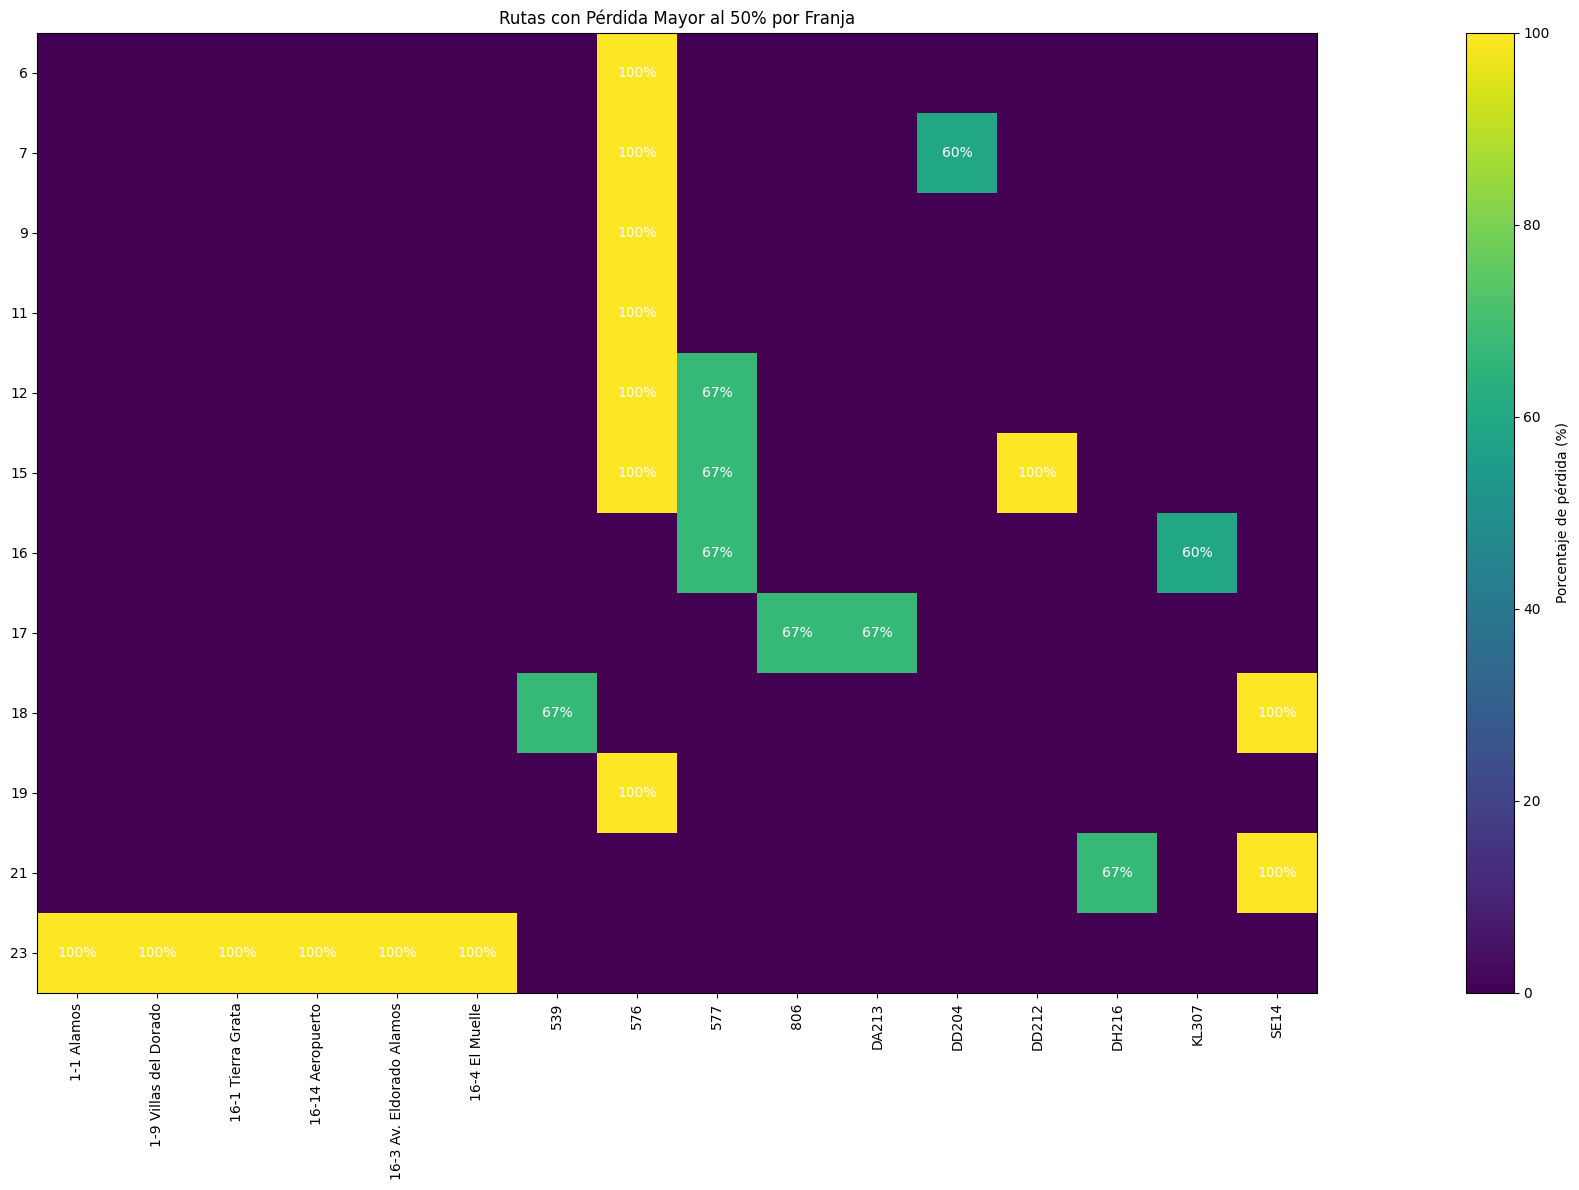

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30,12))

plt.imshow(pivot.values)

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)

# Etiquetas blancas
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        valor = pivot.values[i, j]
        if valor > 0:
            plt.text(
                j, i,
                f"{valor:.0f}%",
                ha="center",
                va="center",
                color="white"
            )

plt.colorbar(label="Porcentaje de pérdida (%)")
plt.title("Rutas con Pérdida Mayor al 50% por Franja")

plt.tight_layout()
plt.show()

In [35]:
perdidos_reg.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_regularidad/datos_regularidad.csv', sep=';', index=False)

In [36]:
perdidos_consecutivos.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_regularidad/datos_regularidad_perdidas_consecutivas.csv', sep=';', index=False)

In [37]:
indicador.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_regularidad/regularidad_perdidas_afectan.csv', sep=';', index=False)